## Problem A: Closest Pair of Points in the Plane, but Nicer

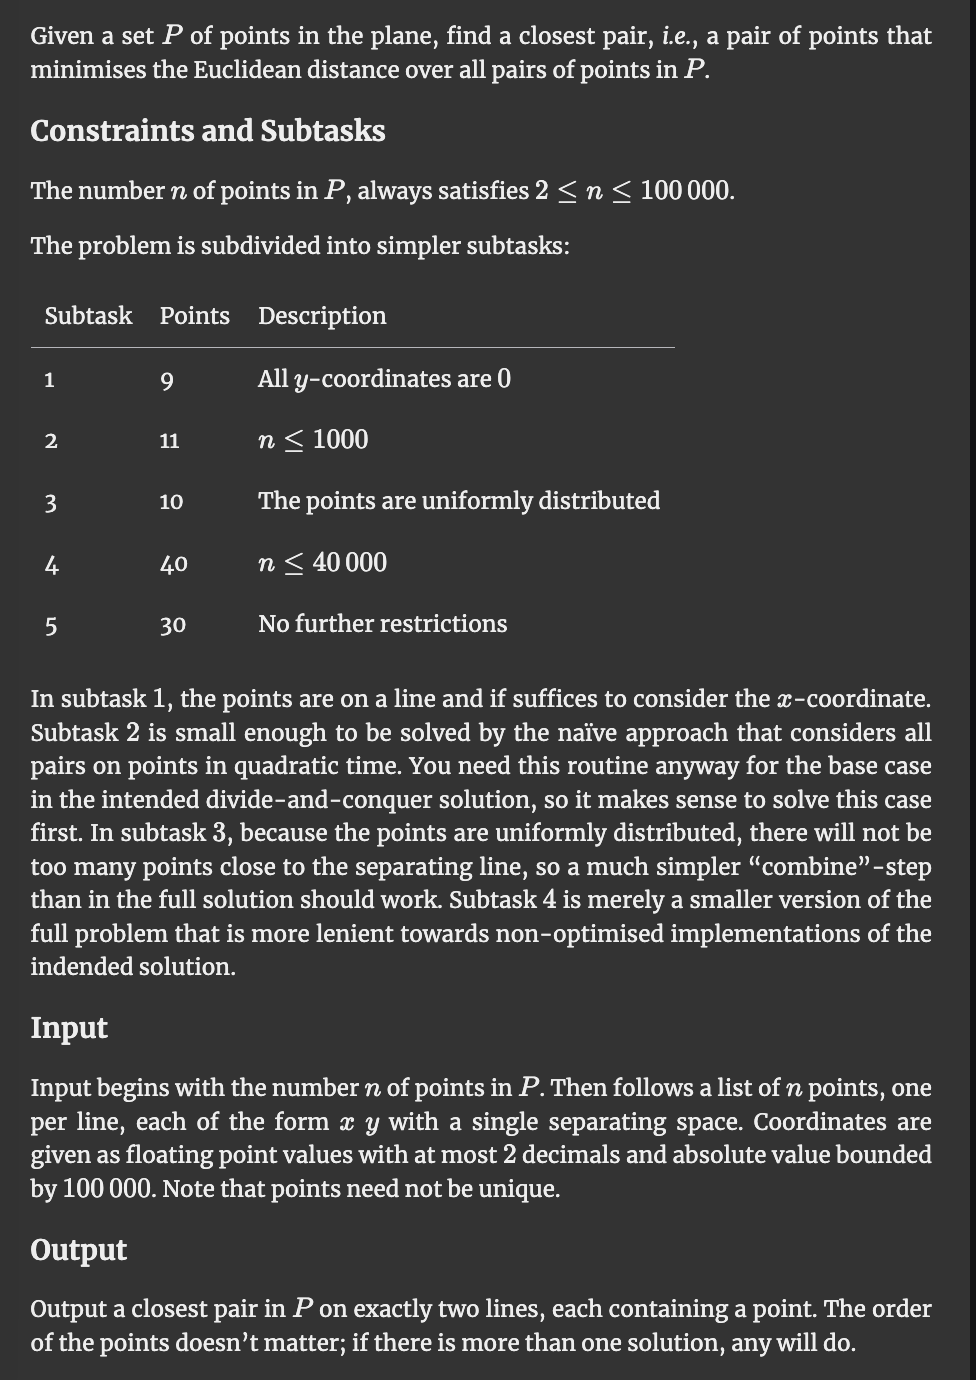

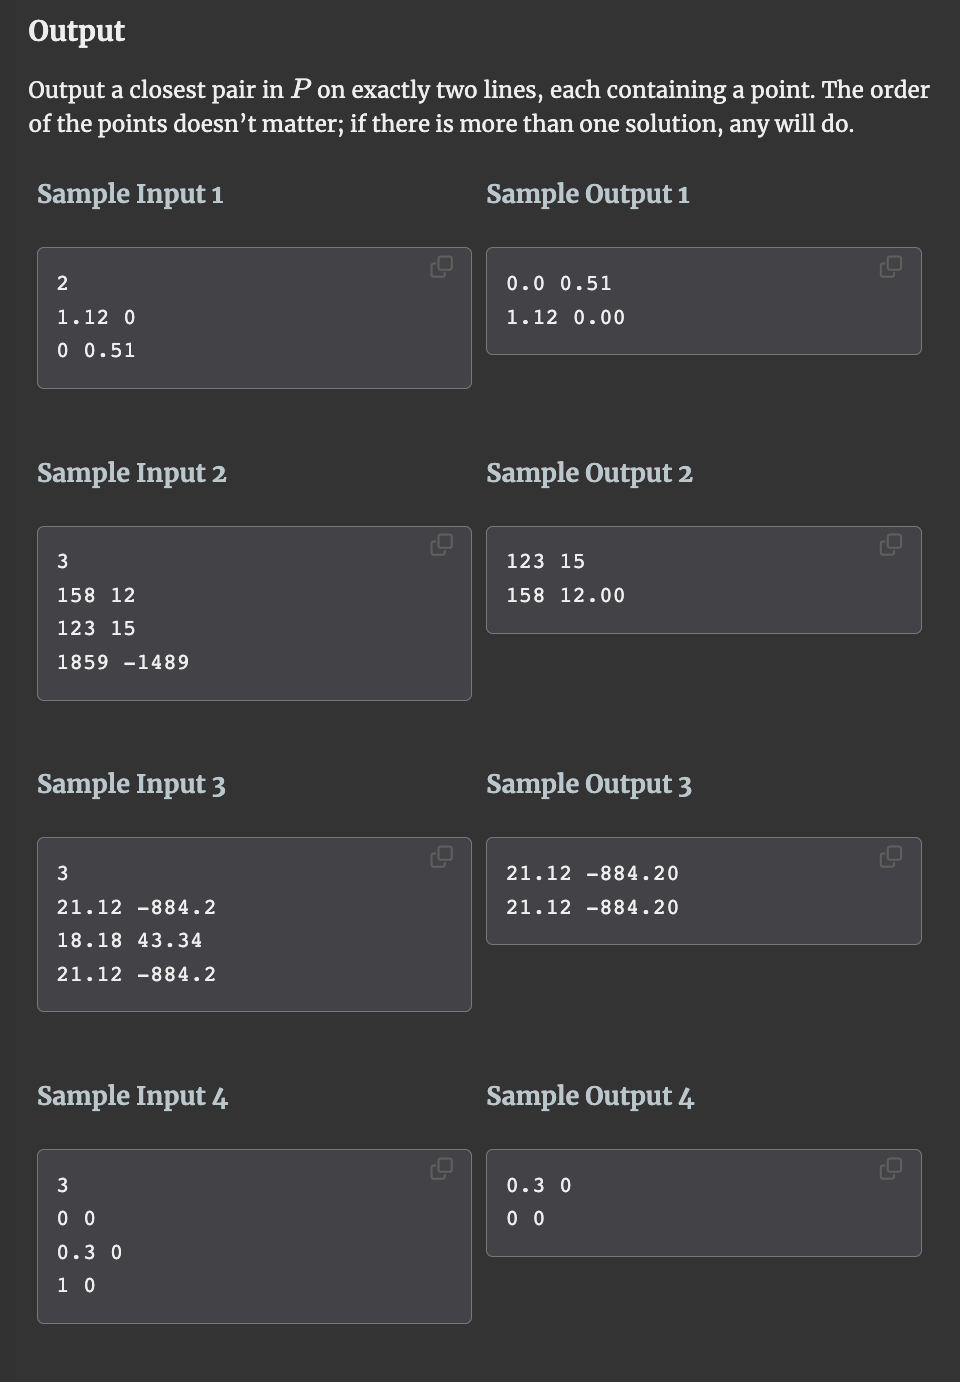

### read-in

In [17]:
sample_input1 = """
3
158 12
123 15
1859 -1489
"""

SyntaxError: invalid syntax (2558364133.py, line 3)

In [ ]:
import sys, io
import numpy as np
import math


# toggle
lines = sys.stdin.read().splitlines()   # real Kattis submission

lines = sample_input1.strip().splitlines()         # local testing

In [3]:
lines

['3', '158 12', '123 15', '1859 -1489']

In [4]:
cursor = 0
tracker = int(lines[cursor]); cursor += 1

list_of_coordinates = []

for line in range(tracker): 
    coordinates = lines[cursor]; cursor += 1
    
    list_of_coordinates.append(coordinates)
    print(f"list_of_coordinates: {list_of_coordinates}")

list_of_coordinates: ['158 12']
list_of_coordinates: ['158 12', '123 15']
list_of_coordinates: ['158 12', '123 15', '1859 -1489']


In [5]:
points = []
for coordinate in list_of_coordinates:
    x1, y1 = map(float, coordinate.split())
    points.append((x1, y1))
    print(points)

[(158.0, 12.0)]
[(158.0, 12.0), (123.0, 15.0)]
[(158.0, 12.0), (123.0, 15.0), (1859.0, -1489.0)]


In [6]:
min_distance = float('inf')
closest_pair = None

for i in range(len(points)):
    for j in range(i + 1, len(points)):
        x1, y1 = points[i]
        x2, y2 = points[j]
        distance = math.hypot(x1 - x2, y1 - y2)
        if distance < min_distance:
            min_distance = distance
            closest_pair = (points[i], points[j])

print(closest_pair)
print(f"{min_distance:.6f}")

((158.0, 12.0), (123.0, 15.0))
35.128336


In [9]:
## Output:

for x, y in closest_pair:
    print(f"{x} {y}")


158.0 12.0
123.0 15.0


The algorithm runs in $n^2$ time by brute forcing all n(n-1)/2 pairs. Divide-and-conquer is faster. For this, we will use the guide: "https://www.geeksforgeeks.org/dsa/closest-pair-of-points-using-divide-and-conquer-algorithm/"

### Divide-and-Conquer Approach

In [13]:
def strip_closest(strip, best_distance, best_pair):
    min_distance = best_distance
    closest_pair = best_pair

    strip = sorted(strip, key=lambda point: point[1])
    num_points = len(strip)

    for i in range(num_points):
        j = i + 1
        while j < num_points:
            y_gap = strip[j][1] - strip[i][1]
            if y_gap >= min_distance:
                break

            x1, y1 = strip[i]
            x2, y2 = strip[j]
            distance = math.hypot(x1 - x2, y1 - y2)

            if distance < min_distance:
                min_distance = distance
                closest_pair = (strip[i], strip[j])

            j += 1

    return min_distance, closest_pair


def closest_util(points):
    num_points = len(points)

    if num_points <= 3:
        return brute_force(points)

    middle_index = num_points // 2
    middle_point = points[middle_index]

    left_points = points[:middle_index]
    right_points = points[middle_index:]

    left_distance, left_pair = closest_util(left_points)
    right_distance, right_pair = closest_util(right_points)

    if left_distance < right_distance:
        best_distance = left_distance
        best_pair = left_pair
    else:
        best_distance = right_distance
        best_pair = right_pair

    strip = []
    for point in points:
        if abs(point[0] - middle_point[0]) < best_distance:
            strip.append(point)

    return strip_closest(strip, best_distance, best_pair)


points_sorted = sorted(points, key=lambda point: point[0])
min_distance, closest_pair = closest_util(points_sorted)

for x, y in closest_pair:
    print(x, y)


123.0 15.0
158.0 12.0


In [14]:
def brute_force(points):
    min_distance = float('inf')
    closest_pair = None
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            x1, y1 = points[i]
            x2, y2 = points[j]
            distance = math.hypot(x1 - x2, y1 - y2)
            if distance < min_distance:
                min_distance = distance
                closest_pair = (points[i], points[j])
    return min_distance, closest_pair


def strip_closest(strip, d, pair):
    strip = sorted(strip, key=lambda p: p[1])
    n = len(strip)
    for i in range(n):
        j = i + 1
        while j < n and (strip[j][1] - strip[i][1]) < d:
            x1, y1 = strip[i]
            x2, y2 = strip[j]
            dist = math.hypot(x1 - x2, y1 - y2)
            if dist < d:
                d = dist
                pair = (strip[i], strip[j])
            j += 1
    return d, pair


def closest_util(points):
    n = len(points)
    if n <= 3:
        return brute_force(points)

    mid = n // 2
    mid_x = points[mid][0]

    dl, pl = closest_util(points[:mid])
    dr, pr = closest_util(points[mid:])

    if dl < dr:
        d, pair = dl, pl
    else:
        d, pair = dr, pr

    strip = [p for p in points if abs(p[0] - mid_x) < d]
    return strip_closest(strip, d, pair)


points_sorted = sorted(points, key=lambda p: p[0])
min_distance, closest_pair = closest_util(points_sorted)

for x, y in closest_pair:
    print(x, y)


123.0 15.0
158.0 12.0


def 

In [15]:
def brute_force(points):
    min_distance = float('inf')
    closest_pair = None

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            x1, y1 = points[i]
            x2, y2 = points[j]
            distance = math.hypot(x1 - x2, y1 - y2)
            if distance < min_distance:
                min_distance = distance
                closest_pair = (points[i], points[j])

    return min_distance, closest_pair


def strip_closest(strip, best_distance, best_pair):
    min_distance = best_distance
    closest_pair = best_pair

    strip = sorted(strip, key=lambda point: point[1])
    num_points = len(strip)

    for i in range(num_points):
        j = i + 1
        while j < num_points:
            y_gap = strip[j][1] - strip[i][1]
            if y_gap >= min_distance:
                break

            x1, y1 = strip[i]
            x2, y2 = strip[j]
            distance = math.hypot(x1 - x2, y1 - y2)

            if distance < min_distance:
                min_distance = distance
                closest_pair = (strip[i], strip[j])

            j += 1

    return min_distance, closest_pair


def closest_util(points):
    num_points = len(points)    #

    if num_points <= 3:
        return brute_force(points)

    middle_index = num_points // 2
    middle_point = points[middle_index]

    left_points = points[:middle_index]
    right_points = points[middle_index:]

    left_distance, left_pair = closest_util(left_points)
    right_distance, right_pair = closest_util(right_points)

    if left_distance < right_distance:
        best_distance = left_distance
        best_pair = left_pair
    else:
        best_distance = right_distance
        best_pair = right_pair

    strip = []
    for point in points:
        if abs(point[0] - middle_point[0]) < best_distance:
            strip.append(point)

    return strip_closest(strip, best_distance, best_pair)


points_sorted = sorted(points, key=lambda point: point[0])
min_distance, closest_pair = closest_util(points_sorted)

for x, y in closest_pair:
    print(x, y)


123.0 15.0
158.0 12.0


In [20]:
#inspiration: https://www.geeksforgeeks.org/dsa/closest-pair-of-points-using-divide-and-conquer-algorithm/

import sys, io
import numpy as np
import math


# change to sys.stdin
lines = sys.stdin.read().splitlines() 

cursor = 0
tracker = int(lines[cursor]); cursor += 1

list_of_coordinates = []

for line in range(tracker): 
    coordinates = lines[cursor]; cursor += 1
    
    list_of_coordinates.append(coordinates)
    #print(f"list_of_coordinates: {list_of_coordinates}")
    
points = []
for coordinate in list_of_coordinates:
    x1, y1 = map(float, coordinate.split())
    points.append((x1, y1))
    #print(points)

    
def brute_force(points):
    min_distance = float('inf')
    closest_pair = None
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            x1, y1 = points[i]
            x2, y2 = points[j]
            distance = math.hypot(x1 - x2, y1 - y2)
            if distance < min_distance:
                min_distance = distance
                closest_pair = (points[i], points[j])
    return min_distance, closest_pair


def strip_closest(strip, d, pair):
    strip = sorted(strip, key=lambda p: p[1])
    n = len(strip)
    for i in range(n):
        j = i + 1
        while j < n and (strip[j][1] - strip[i][1]) < d:
            x1, y1 = strip[i]
            x2, y2 = strip[j]
            dist = math.hypot(x1 - x2, y1 - y2)
            
            if dist < d:
                d = dist
                pair = (strip[i], strip[j])
            j += 1
    return d, pair


def closest_util(points):
    n = len(points)
    if n <= 3:
        return brute_force(points)

    mid = n // 2
    mid_x = points[mid][0]

    dist_left, pair_left = closest_util(points[:mid])
    dist_right, pair_right = closest_util(points[mid:])


    if dist_left < dist_right:
        d, pair = dist_left, pair_left
    else:
        d, pair = dist_right, pair_right


    strip = [p for p in points if abs(p[0] - mid_x) < d]
    return strip_closest(strip, d, pair)


points_sorted = sorted(points, key=lambda p: p[0])
min_distance, closest_pair = closest_util(points_sorted)

for x, y in closest_pair:
    print(x, y)


123.0 15.0
158.0 12.0


In [22]:
#inspiration: https://www.geeksforgeeks.org/dsa/closest-pair-of-points-using-divide-and-conquer-algorithm/

import math
import sys

# toggle
lines = sys.stdin.read().splitlines() 

cursor = 0
tracker = int(lines[cursor]); cursor += 1

list_of_coordinates = []

for line in range(tracker): 
    coordinates = lines[cursor]; cursor += 1
    
    list_of_coordinates.append(coordinates)
    #print(f"list_of_coordinates: {list_of_coordinates}")
    
points = []
for coordinate in list_of_coordinates:
    x1, y1 = map(float, coordinate.split())
    points.append((x1, y1))
    #print(points)

def brute_force(points):
    min_distance = float('inf')
    closest_pair = None
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            x1, y1 = points[i]
            x2, y2 = points[j]
            distance = math.hypot(x1 - x2, y1 - y2)
            if distance < min_distance:
                min_distance = distance
                closest_pair = (points[i], points[j])
    return min_distance, closest_pair


def strip_closest(strip, d, pair):
    strip = sorted(strip, key=lambda p: p[1])
    n = len(strip)
    for i in range(n):
        j = i + 1
        while j < n and (strip[j][1] - strip[i][1]) < d:
            x1, y1 = strip[i]
            x2, y2 = strip[j]
            dist = math.hypot(x1 - x2, y1 - y2)
            
            if dist < d:
                d = dist
                pair = (strip[i], strip[j])
            j += 1
    return d, pair


def closest_util(points):
    n = len(points)
    if n <= 3:
        return brute_force(points)

    mid = n // 2
    mid_x = points[mid][0]

    dist_left, pair_left = closest_util(points[:mid])
    dist_right, pair_right = closest_util(points[mid:])

    #keep distnace of closest points in each side
    if dist_left < dist_right:
        d, pair = dist_left, pair_left
    else:
        d, pair = dist_right, pair_right


    strip = [p for p in points if abs(p[0] - mid_x) < d]
    return strip_closest(strip, d, pair)


points_sorted = sorted(points, key=lambda p: p[0])
min_distance, closest_pair = closest_util(points_sorted)

for x, y in closest_pair:
    print(x, y)


123.0 15.0
158.0 12.0


In [ ]:
#   fi